#### Previo
Se importan los paquetes y se aplica el formato general

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as wid
from scipy.optimize import curve_fit
from scipy.ndimage import gaussian_filter1d
import colorcet as cc
import os
import copy
from matplotlib.patches import FancyBboxPatch
import uncertainties as un
from uncertainties.umath import *

Se configuran las gráficas, tengase en cuenta que algunos pueden no cargar por dependencias a instalar pendientes.


In [2]:
%matplotlib widget
mpl.rcParams.update(
    {
        "legend.fontsize": 20,
        "axes.labelsize": 24,  # Updated from 20 to 24
        "axes.titlesize": 24,
        "xtick.labelsize": 20,
        "ytick.labelsize": 20,
        "figure.titlesize": 24,
        "axes.titlepad": 10,
        "text.usetex": True,
        "font.family": "Times New Roman",
        "mathtext.fontset": "dejavusans",
        "font.size": 20,
        "axes.labelweight": "bold",
        "axes.grid.which": "both",
        "axes.grid": True,
        "grid.alpha": 0.5,
        "axes.formatter.limits": (-3, 3),  # Use scientific notation for values outside the range 10^-3 to 10^3
        'figure.subplot.bottom': 0.2  
    }
)

colors = cc.glasbey_category10
# Configuracion de colores
k = 0

# Rotar la lista: número positivo para rotar a la derecha, negativo para rotar a la izquierda
colors = colors[-k:] + colors[:-k]

plt.rcParams["axes.prop_cycle"] = plt.cycler(color=colors)

# Test
if False:
    plt.figure(figsize=(5, 5))
    plt.plot([1, 2, 3, 4], [1, 4, 9, 16], "o")
    plt.plot([4, 3, 2, 1], [1, 2, 3, 4], "o")
    plt.plot([1, 2, 3, 4], [1, 2, 3, 4], "s")
    plt.plot([4, 3, 2, 1], [1, 4, 9, 16], "s")
    plt.title("Test")
    plt.xlabel("X-axis Label", fontweight="bold")
    plt.ylabel("Y-axis Label")
    plt.show()

# Práctica 8: Difracción

Por Andrés Felipe Pinzón Harker
    Cristian Camilo Perez Puentes

Universidad Nacional de Colombia. Departamento de Física.

Mediciones en Óptica y Acústica

## Introducción

## Metodología Experimental

## Análisis y Resultados

Al realizar los perfiles de luminancia de los patrones de difracción

In [ ]:
pre_dir = "data/"
files = ["perfil_F3_P1.dat", "perfil_F3_P2.dat", "perfil_F3_P3.dat"]
data = {}

for file in files:
    df = pd.read_csv(pre_dir + file, usecols=[1, 2], skiprows=1)
    data[file[:-4]] = df

print(data)

ValueError: Usecols do not match columns, columns expected but not found: [1, 2]

a: 227.5439
mu: -0.0657
sigma: 2.9290


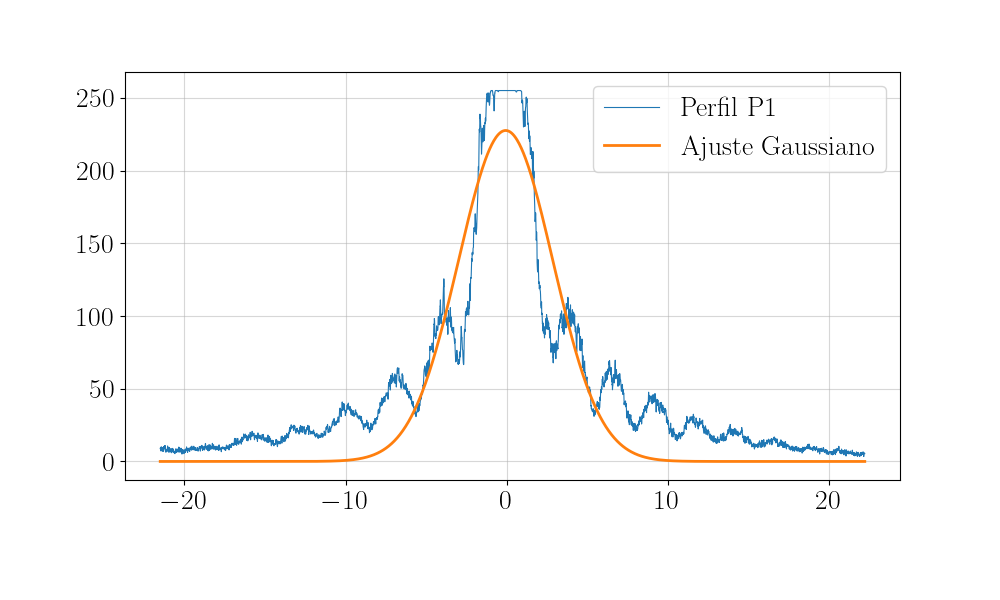

In [33]:
pre_dir = "data/"
df = pd.read_csv(pre_dir + "perfil_F3_P4.dat", usecols=[1, 2], skiprows=1)
plt.figure(figsize=(10, 6))
plt.plot(df["x"], df["luma"], lw=0.8, label="Perfil P1")
def gauss(x, a, mu, sigma):
    return a * np.exp(-(x - mu)**2 / (2 * sigma**2))

popt, pcov = curve_fit(gauss, df["x"], df["luma"], p0=[200, 0, 1])
x_fit = np.linspace(df["x"].min(), df["x"].max(), 1000)
y_fit = gauss(x_fit, *popt)
for param, value in zip(["a", "mu", "sigma"], popt):
    print(f"{param}: {value:.4f}")
plt.plot(x_fit, y_fit, color=colors[1], lw=2, label="Ajuste Gaussiano")
plt.legend()
plt.show()

In [26]:
print(*popt, sep="\n")

225.27450871149608
-0.23663870035177254
1.4579195855278657
